# Unemployment Analysis in India

This project analyzes unemployment trends across Indian states from 2019 to 2020,
with a focus on the impact of the COVID-19 lockdown. We explore regional patterns,
urban vs rural differences, and how employment figures shifted before and after April 2020.

**Dataset:** Unemployment in India — Kaggle  
**Key columns:** Region, Date, Area (Urban/Rural), Estimated Unemployment Rate (%), Estimated Employed, Estimated Labour Participation Rate (%)

In [1]:
import pandas as pd 
import numpy as np 
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns 

## 1. Load the Data

In [2]:
df = pd.read_csv("Unemployment in India.csv")

## 2. Data Overview & Cleaning
First look at the dataset — shape, types, column names, and quality check before any analysis.

In [3]:
df.shape

(768, 7)

In [4]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [6]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

### Strip whitespace from column names
Column names had leading/trailing spaces which would cause `KeyError` when accessed — stripped here.

In [7]:
df.columns = df.columns.str.strip()

In [8]:
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

### Drop irrelevant columns
`Frequency` contains the same value ("Monthly") for every row — it adds no information and is dropped.

In [9]:
df.drop(columns=['Frequency'], inplace=True)

In [10]:
df['Date'] = pd.to_datetime(df['Date'])

C:\Users\Vedant Birla\AppData\Local\Temp\ipykernel_22604\2394721818.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [11]:
type(df['Date'].values.dtype)

numpy.dtypes.DateTime64DType

### Statistical Summary

In [12]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Region,740,28,Andhra Pradesh,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date,740,NaN,NaN,NaN,2019-12-12 18:36:58.378378496,2019-05-31 00:00:00,2019-08-31 00:00:00,2019-11-30 00:00:00,2020-03-31 00:00:00,2020-06-30 00:00:00,NaN
Estimated Unemployment Rate (%),740.0,NaN,NaN,NaN,11.787946,0.0,4.6575,8.35,15.8875,76.74,10.721298
Estimated Employed,740.0,NaN,NaN,NaN,7204460.025676,49420.0,1190404.5,4744178.5,11275489.5,45777509.0,8087988.429458
Estimated Labour Participation Rate (%),740.0,NaN,NaN,NaN,42.630122,13.33,38.0625,41.16,45.505,72.57,8.111094
Area,740,2,Urban,381,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Missing Value Check

In [13]:
df.isna().sum()

Region                                     28
Date                                       28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

In [14]:
(df.isna().sum() / df.shape[0]) * 100

Region                                     3.645833
Date                                       3.645833
Estimated Unemployment Rate (%)            3.645833
Estimated Employed                         3.645833
Estimated Labour Participation Rate (%)    3.645833
Area                                       3.645833
dtype: float64

### Visualizing Missing Values
The bar chart below shows what percentage of each column has missing data — helps decide
whether to drop or impute.

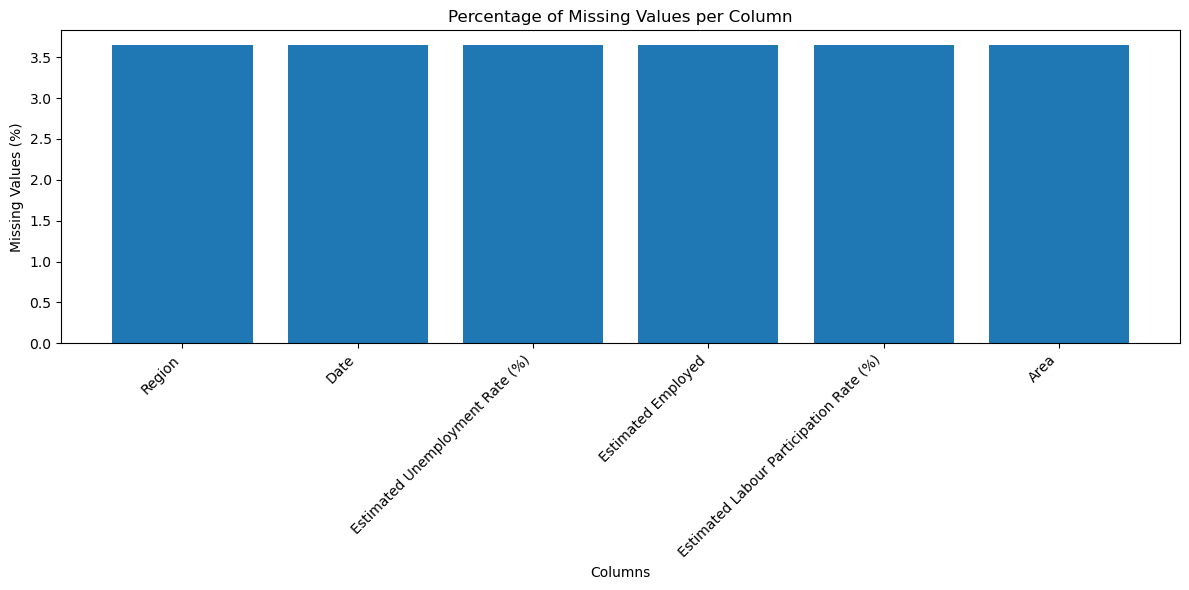

In [15]:
plt.figure(figsize=(12, 6))
plt.bar(x= df.columns, height= (df.isna().sum() / df.shape[0]) * 100 )
plt.title('Percentage of Missing Values per Column')
plt.ylabel('Missing Values (%)')
plt.xlabel('Columns')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Imputing Missing Values
- **Categorical columns** (`Region`, `Area`) → filled with the **mode** (most frequent value), since these are labels with no numeric meaning.
- **Numeric columns** → filled with the **median**, which is more robust to outliers than the mean.

In [16]:
cat_cols = df.select_dtypes('object').columns
cat_cols

Index(['Region', 'Area'], dtype='object')

## 3. Exploratory Data Analysis (EDA)
Exploring the distribution of categorical and numeric features to understand the dataset
before drawing conclusions.

In [17]:
for i in cat_cols:
    df[i].fillna(value= df[i].mode()[0] , inplace=True)

C:\Users\Vedant Birla\AppData\Local\Temp\ipykernel_22604\2218172583.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(value= df[i].mode()[0] , inplace=True)


In [18]:
num_cols = df.select_dtypes(['float64' , 'datetime64[ns]']).columns
num_cols

Index(['Date', 'Estimated Unemployment Rate (%)', 'Estimated Employed',
       'Estimated Labour Participation Rate (%)'],
      dtype='object')

In [19]:
for i in num_cols:
    df[i].fillna(value= df[i].median() , inplace=True)

C:\Users\Vedant Birla\AppData\Local\Temp\ipykernel_22604\1543731380.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(value= df[i].median() , inplace=True)


In [20]:
df.isna().sum()

Region                                     0
Date                                       0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

In [23]:
cat_cols

Index(['Region', 'Area'], dtype='object')

In [24]:
for i in cat_cols:
    print(df[i].value_counts())
    print('Number of Keys = ', len(df[i].value_counts().keys()))
    print('-' * 20)

Region
Andhra Pradesh      56
Bihar               28
Chhattisgarh        28
Delhi               28
Karnataka           28
Gujarat             28
Haryana             28
Himachal Pradesh    28
Jharkhand           28
Maharashtra         28
Madhya Pradesh      28
Kerala              28
West Bengal         28
Uttar Pradesh       28
Tripura             28
Odisha              28
Rajasthan           28
Punjab              28
Telangana           28
Tamil Nadu          28
Uttarakhand         27
Meghalaya           27
Assam               26
Puducherry          26
Goa                 24
Jammu & Kashmir     21
Sikkim              17
Chandigarh          12
Name: count, dtype: int64
Number of Keys =  28
--------------------
Area
Urban    409
Rural    359
Name: count, dtype: int64
Number of Keys =  2
--------------------


### Regional Distribution
India's states and union territories are not equally represented in the dataset.
The pie chart shows the share of observations per region — a roughly balanced dataset means
no single state dominates the trend analysis.

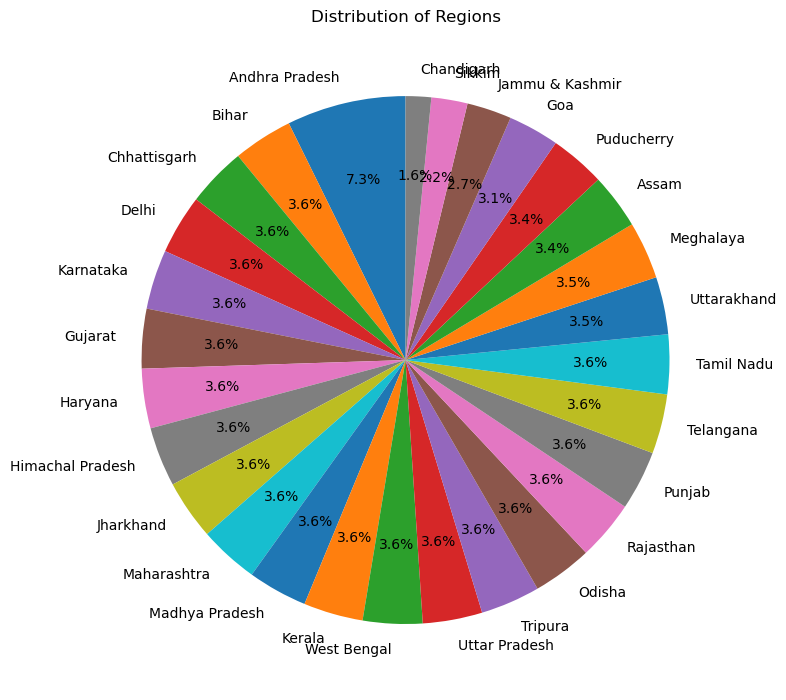

In [25]:
plt.figure(figsize=(8,8))
plt.pie(
    df['Region'].value_counts().values,
    labels=df['Region'].value_counts().index,
    autopct='%1.1f%%',     
    startangle=90,         
    pctdistance=0.7,       
    labeldistance=1.1       
)
plt.title('Distribution of Regions')
plt.tight_layout()
plt.show()

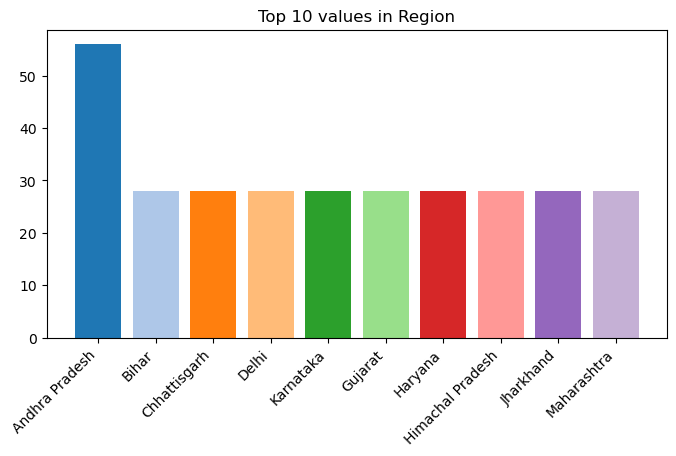

In [26]:
plt.figure(figsize=(8,4))
plt.bar(x=df['Region'].value_counts()[:10].keys(),
            height=df['Region'].value_counts()[:10].values,
            color=plt.cm.tab20.colors)
plt.title(f'Top 10 values in Region')
plt.xticks(rotation=45, ha='right')
plt.show()

### Urban vs Rural Breakdown
The dataset distinguishes between **Urban** and **Rural** areas. Understanding the split
is important because unemployment patterns differ significantly between the two — urban
areas are typically more affected by sudden economic shocks like lockdowns.

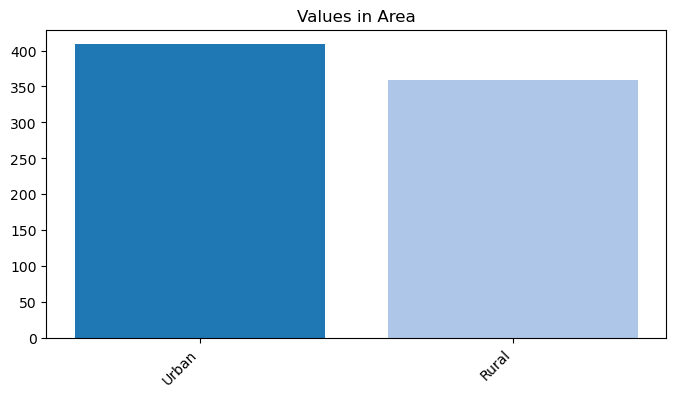

In [27]:
plt.figure(figsize=(8,4))
plt.bar(x=df['Area'].value_counts().keys(),
            height=df['Area'].value_counts().values,
            color=plt.cm.tab20.colors)
plt.title(f'Values in Area')
plt.xticks(rotation=45, ha='right')
plt.show()

### Area Distribution per Region
Some states have data for both Urban and Rural areas; others may only have one.
This stacked chart confirms coverage, so we know which comparisons are valid later.

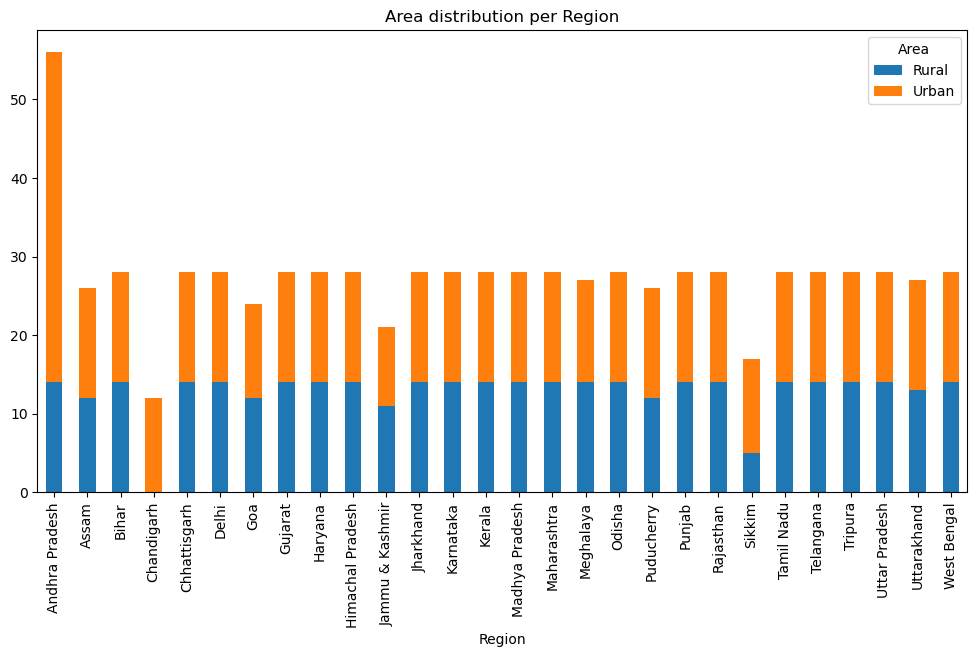

In [28]:
pd.crosstab(df['Region'], df['Area']).plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Area distribution per Region')
plt.show()

In [29]:
num_cols[1:]

Index(['Estimated Unemployment Rate (%)', 'Estimated Employed',
       'Estimated Labour Participation Rate (%)'],
      dtype='object')

### Numeric Feature Distributions
Histograms and boxplots for all numeric columns reveal skewness, typical ranges,
and outliers in unemployment rate, employed count, and labour participation rate.

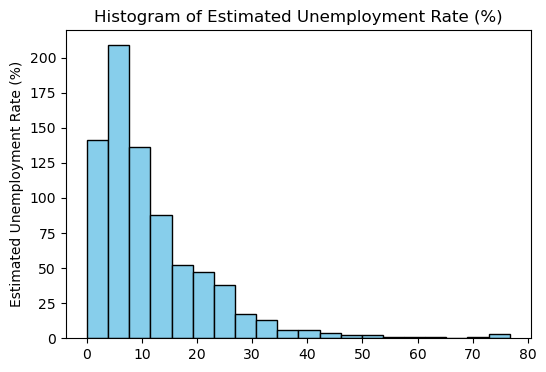

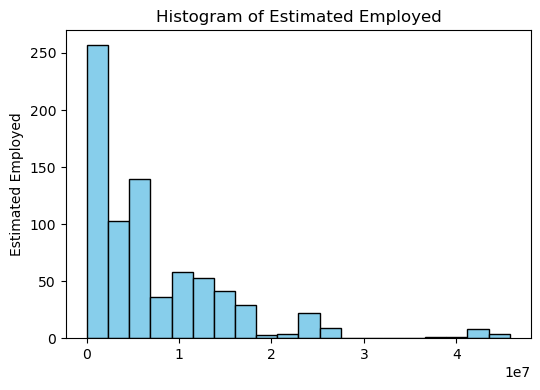

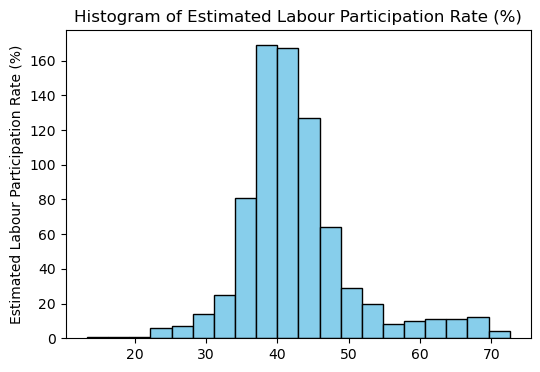

In [30]:
for i in num_cols[1:]:
    plt.figure(figsize=(6,4))
    plt.hist(df[i], bins=20, edgecolor='black', color='skyblue')
    plt.title(f'Histogram of {i}')
    plt.ylabel(i)
    plt.show()

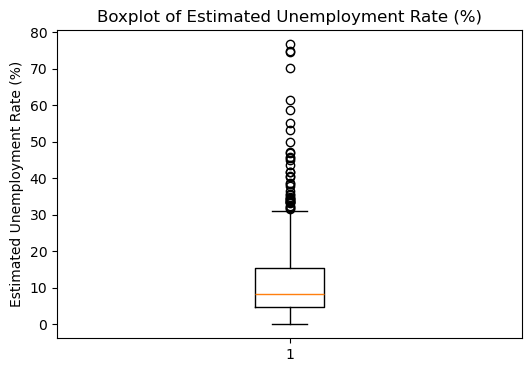

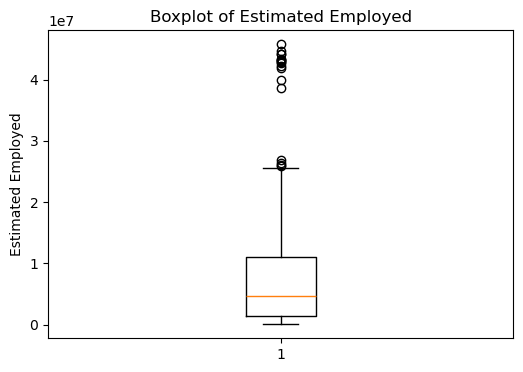

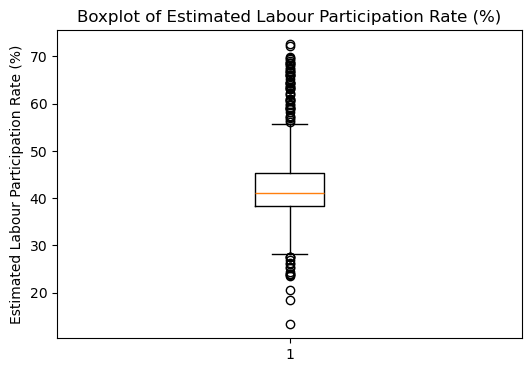

In [31]:
for i in num_cols[1:]:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[i])
    plt.title(f'Boxplot of {i}')
    plt.ylabel(i)
    plt.show()

### Unemployment Rate: Urban vs Rural
> **Insight:** Urban areas consistently show higher unemployment rates than rural areas.
> This is partly because rural employment is dominated by agriculture, which is less
> sensitive to economic shutdowns. Urban formal-sector jobs were hit much harder
> during the COVID-19 lockdown.

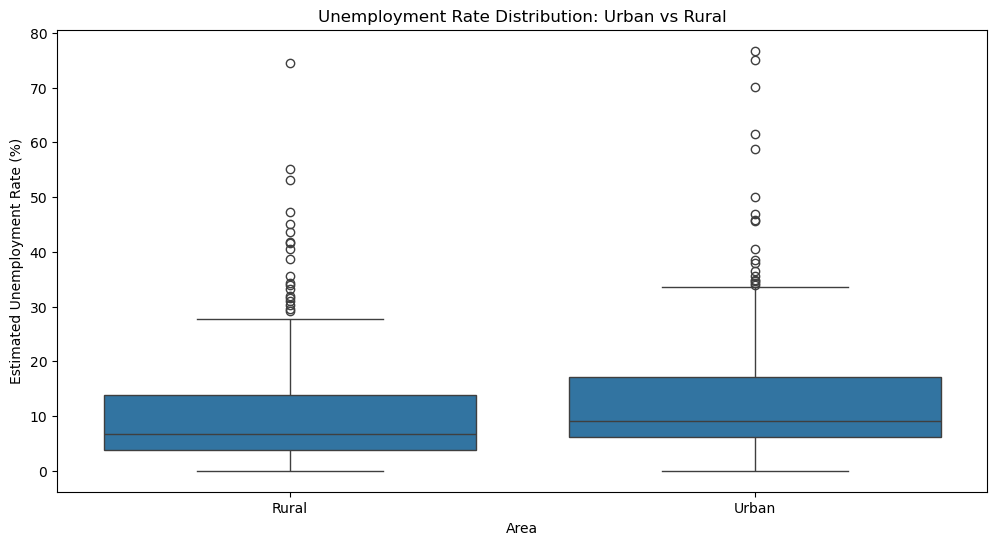

In [32]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Area', y='Estimated Unemployment Rate (%)', data=df)
plt.title('Unemployment Rate Distribution: Urban vs Rural')
plt.show()

### Unemployment Rate by Region and Area
Breaking down the Urban/Rural gap at the state level reveals which states had the
largest disparity. High-disparity states are worth targeting with differentiated
urban employment policies.

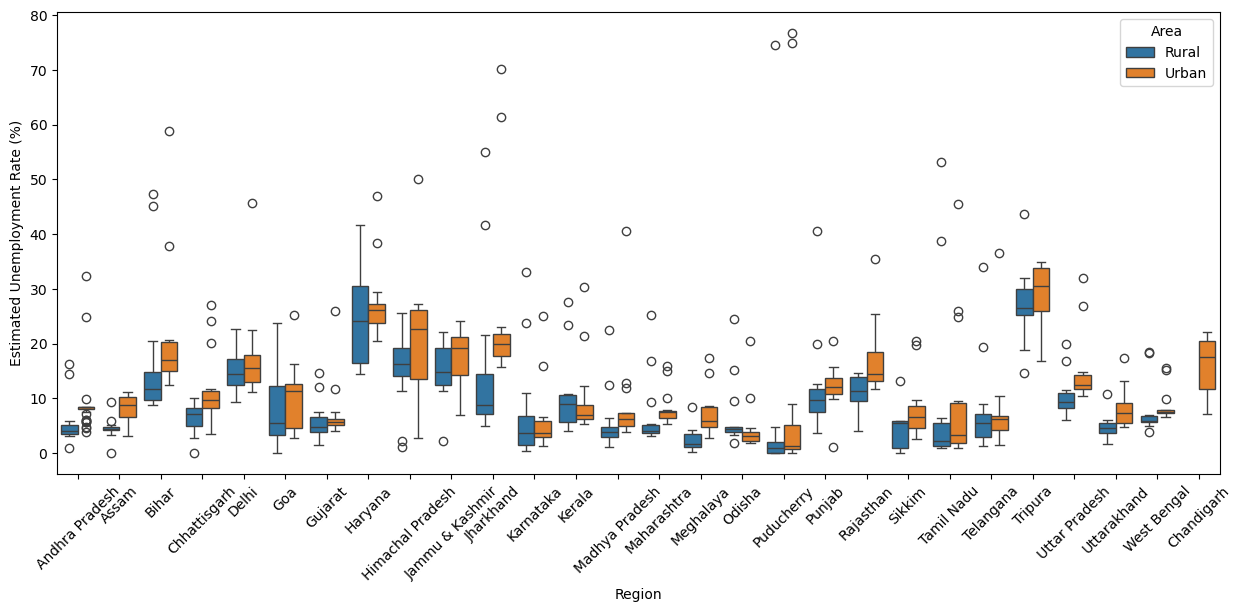

In [33]:
plt.figure(figsize=(15,6))
sns.boxplot(x='Region', y='Estimated Unemployment Rate (%)',hue='Area',  data=df)
plt.xticks(rotation=45)
plt.show()

## 4. Unemployment Trends Over Time
Time-series analysis to see how the national unemployment rate evolved month by month.

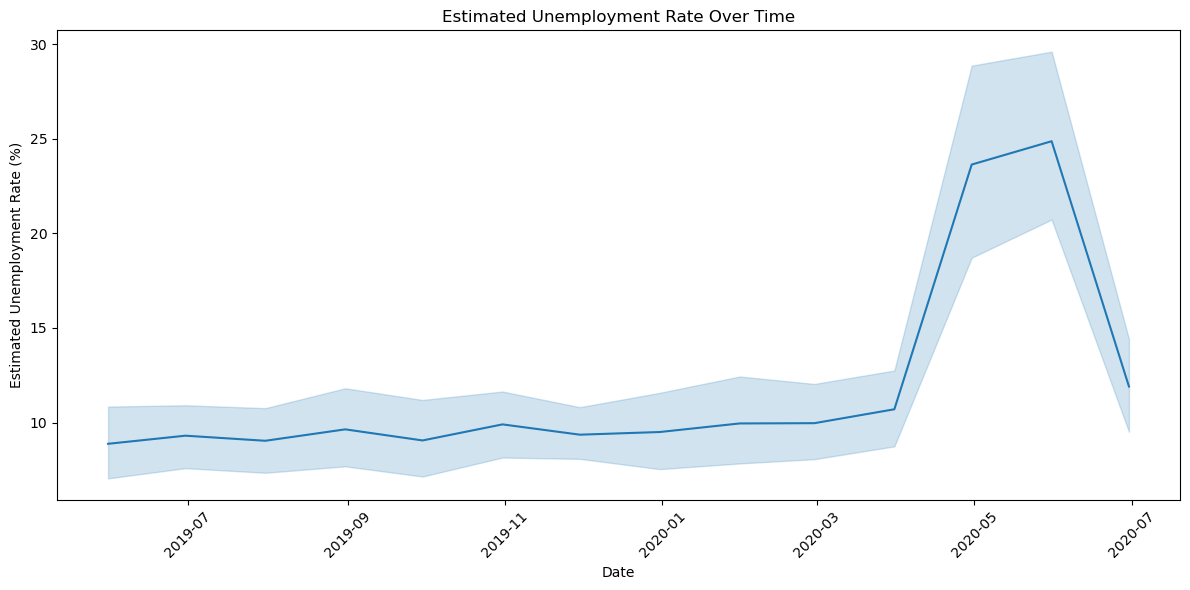

In [34]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df , y='Estimated Unemployment Rate (%)', x='Date')
plt.title('Estimated Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### State-Level Unemployment Trends (Top 10 Regions)
While the national average smooths out state differences, individual states tell a
more nuanced story. Some states spiked sharply in April–May 2020 and recovered quickly;
others showed a slower, more prolonged rise.

C:\Users\Vedant Birla\AppData\Local\Temp\ipykernel_22604\1335296778.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


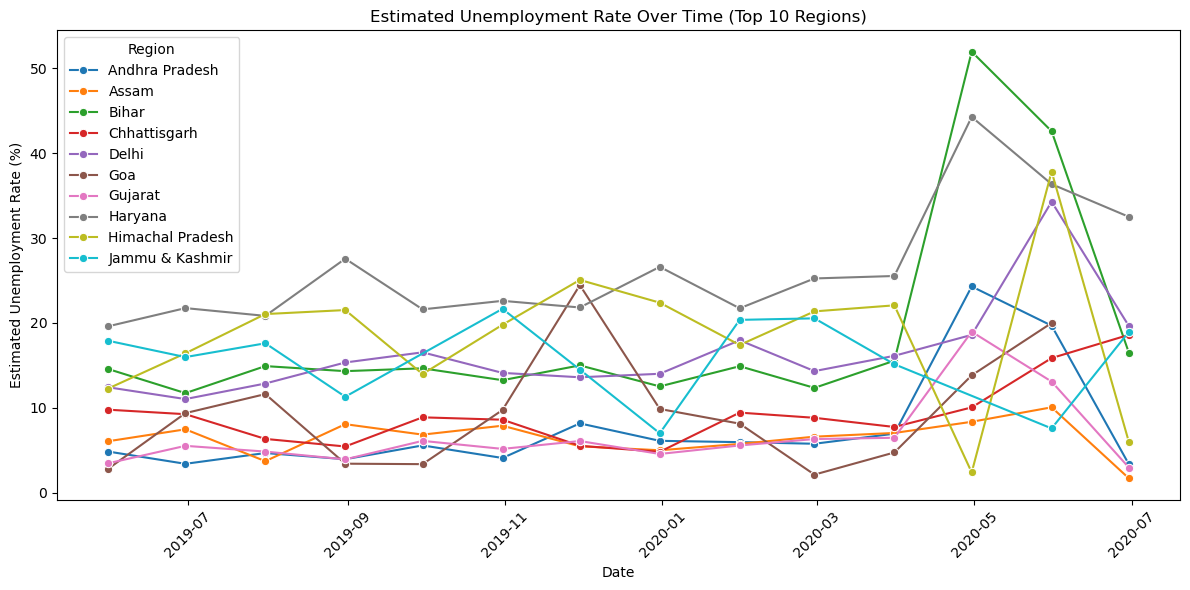

In [35]:
top_regions = df['Region'].unique()[:10]
df_top = df[df['Region'].isin(top_regions)]

plt.figure(figsize=(12,6))
sns.lineplot(
    data=df_top, x='Date', y='Estimated Unemployment Rate (%)', 
    hue='Region', marker='o',ci=None
)
plt.xticks(rotation=45)
plt.title('Estimated Unemployment Rate Over Time (Top 10 Regions)')
plt.tight_layout()
plt.show()

### COVID-19 Impact on National Unemployment
> **Key insight:** The national unemployment rate surged from roughly 8–9% in early 2020
> to a peak above 20% during the April–May 2020 lockdown — more than doubling in under
> two months. The orange band marks the lockdown period. The rate began recovering from
> June 2020 as restrictions were progressively eased.

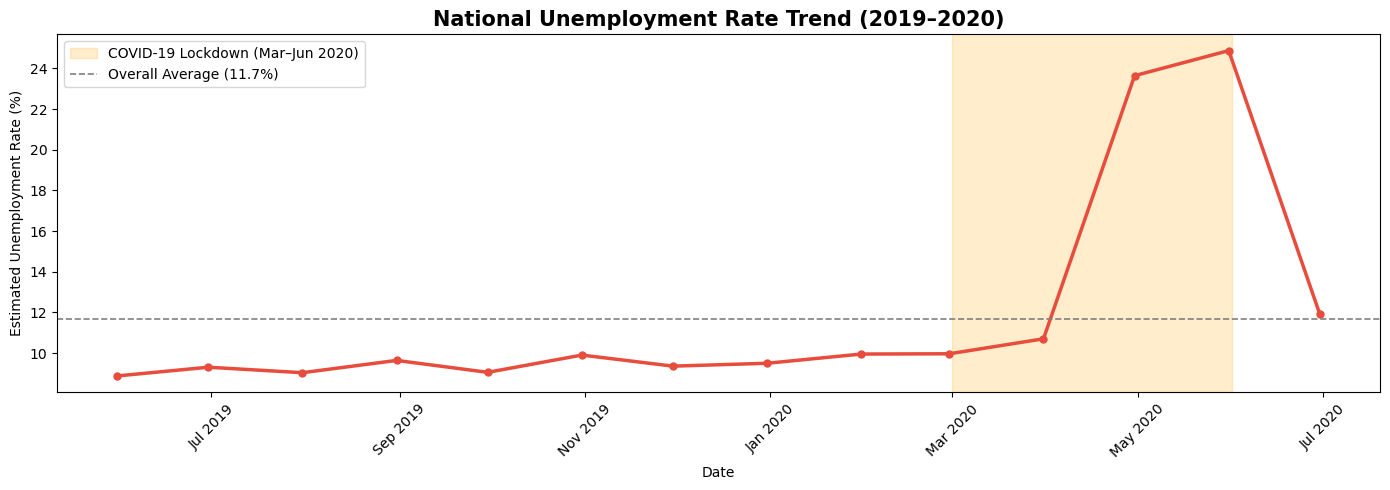

In [50]:
# Average unemployment rate per month across all regions
monthly_avg = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(monthly_avg['Date'], monthly_avg['Estimated Unemployment Rate (%)'],
         color='#e74c3c', linewidth=2.5, marker='o', markersize=5)

# Highlight Covid-19 period
plt.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-06-01'),
            alpha=0.2, color='orange', label='COVID-19 Lockdown (Mar–Jun 2020)')

plt.axhline(y=df['Estimated Unemployment Rate (%)'].mean(), color='gray',
            linestyle='--', linewidth=1.2, label=f"Overall Average ({df['Estimated Unemployment Rate (%)'].mean():.1f}%)")

plt.title('National Unemployment Rate Trend (2019–2020)', fontsize=15, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Regional Heatmap — Unemployment Rate by Month
The heatmap makes it easy to spot which states were hit hardest and when.
Darker red cells indicate peak unemployment. States like Tripura and Haryana
show consistently high rates, while southern states like Karnataka and Tamil Nadu
show a sharper but shorter spike during the lockdown months.

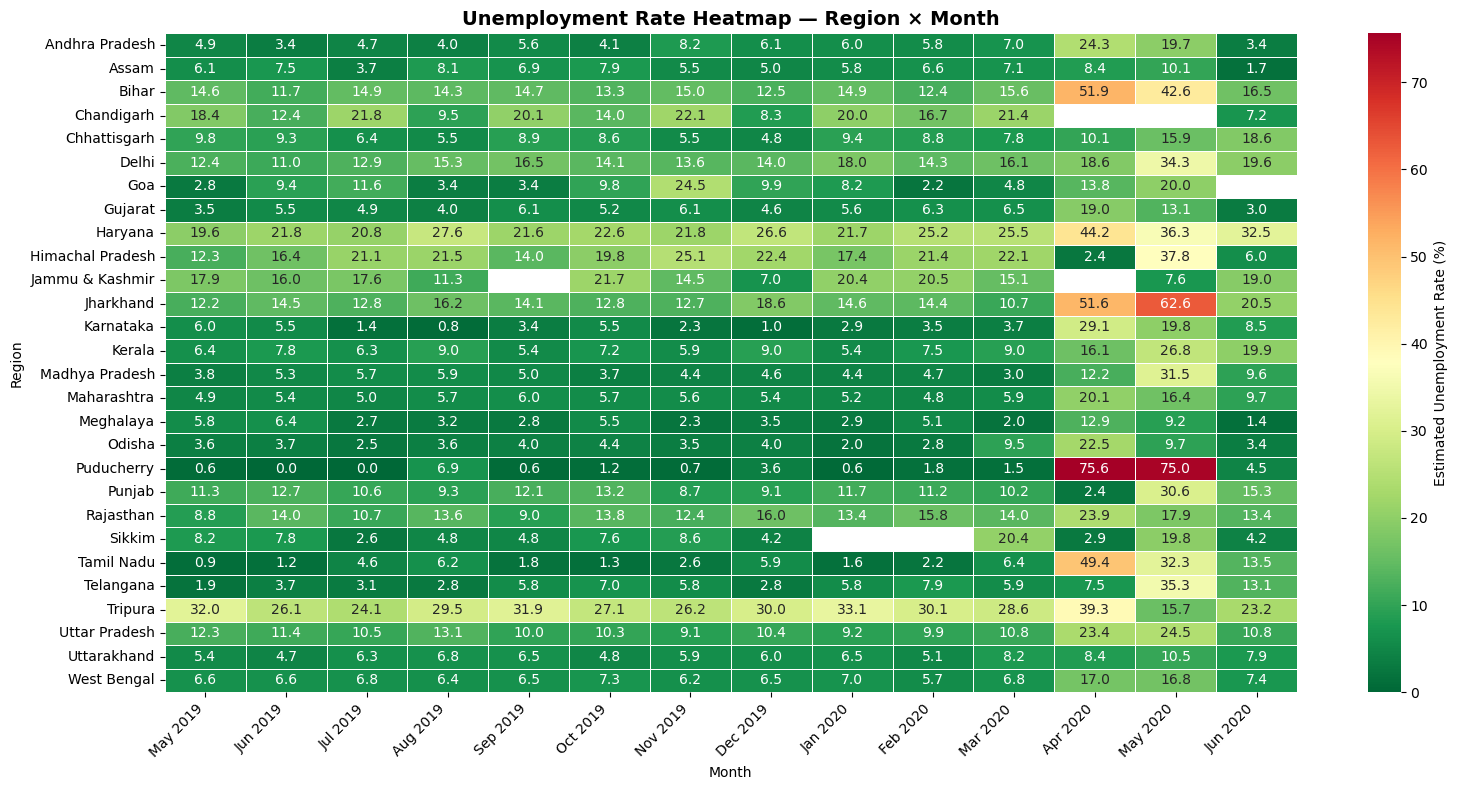

In [51]:
# Pivot table: Region × Month
pivot = df.pivot_table(values='Estimated Unemployment Rate (%)',
                       index='Region',
                       columns=df['Date'].dt.strftime('%b %Y'),
                       aggfunc='mean')

# Sort columns chronologically
pivot = pivot[sorted(pivot.columns, key=lambda x: pd.to_datetime(x, format='%b %Y'))]

plt.figure(figsize=(16, 8))
sns.heatmap(pivot, cmap='RdYlGn_r', annot=True, fmt='.1f',
            linewidths=0.5, cbar_kws={'label': 'Estimated Unemployment Rate (%)'})
plt.title('Unemployment Rate Heatmap — Region × Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Region')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Feature Correlations
Understanding how unemployment rate, employed population, and labour participation
relate to each other.

> **Insight:** Labour Participation Rate and Unemployment Rate tend to move together
> during crises — when the economy contracts, discouraged workers drop out of the
> labour force entirely, which can actually *lower* the unemployment rate even as
> conditions worsen. This "discouraged worker effect" is visible in the correlation here.

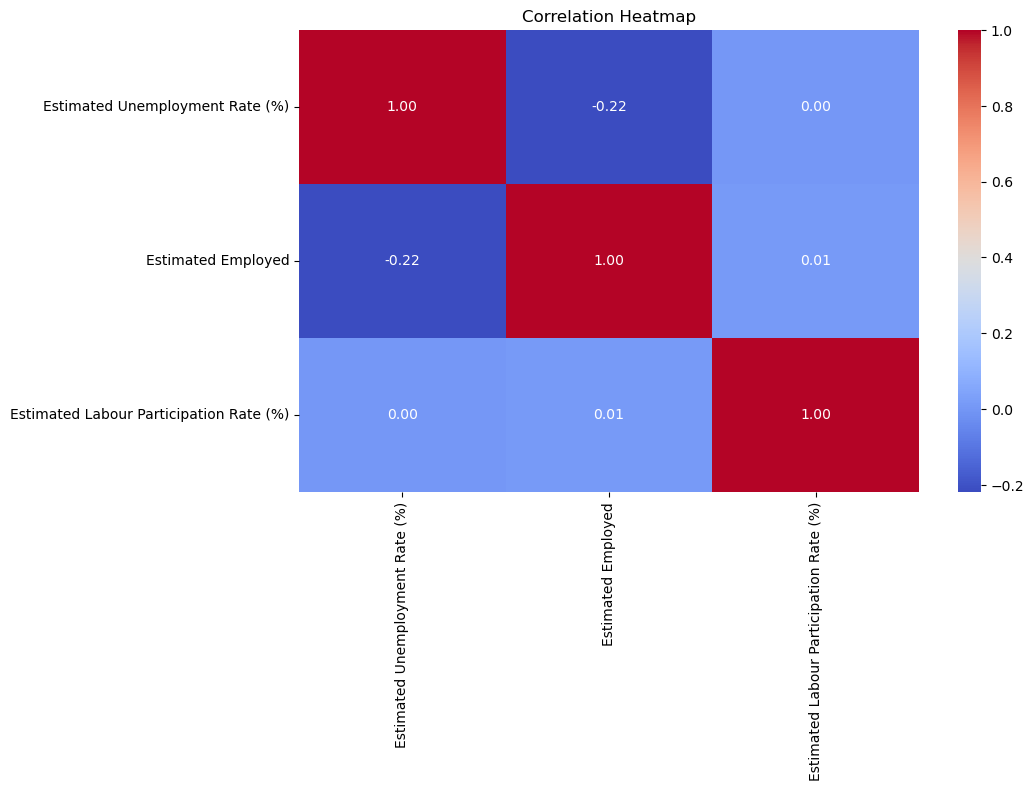

In [36]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['Estimated Unemployment Rate (%)', 
                'Estimated Employed', 
                'Estimated Labour Participation Rate (%)']].corr(), 
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

### Average Unemployment Rate per State (Full Period)
Ranks all states by their average unemployment rate across the entire dataset.
States at the top of this chart face structural unemployment challenges beyond just
the COVID-19 shock and may need longer-term policy intervention.

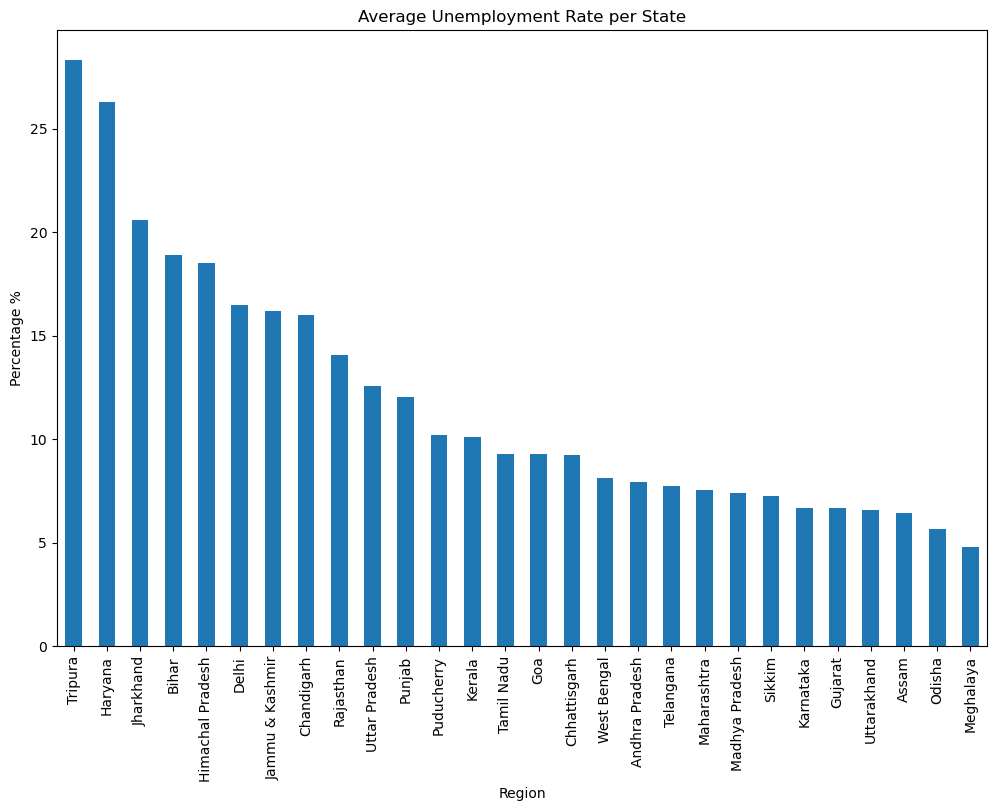

In [37]:
state_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)
plt.figure(figsize=(12,8))
state_avg.plot(kind='bar')
plt.title('Average Unemployment Rate per State')
plt.ylabel('Percentage %')
plt.show()

## 6. COVID-19 Impact Analysis
Splitting the data at April 2020 — the start of India's national lockdown — to
quantify exactly how much unemployment rose.

In [38]:
before_lockdown = df[df['Date'] < '2020-04-01']
during_lockdown = df[df['Date'] >= '2020-04-01']

print(f"Average Unemployment Before: {before_lockdown['Estimated Unemployment Rate (%)'].mean():.2f}%")
print(f"Average Unemployment During: {during_lockdown['Estimated Unemployment Rate (%)'].mean():.2f}%")

Average Unemployment Before: 9.56%
Average Unemployment During: 20.19%


### Before vs After Lockdown Threshold
The red dashed line marks April 1, 2020. Everything to the right of it reflects
lockdown and post-lockdown conditions. The sharp vertical jump in the line is the
clearest visual evidence of the lockdown's immediate impact on employment.

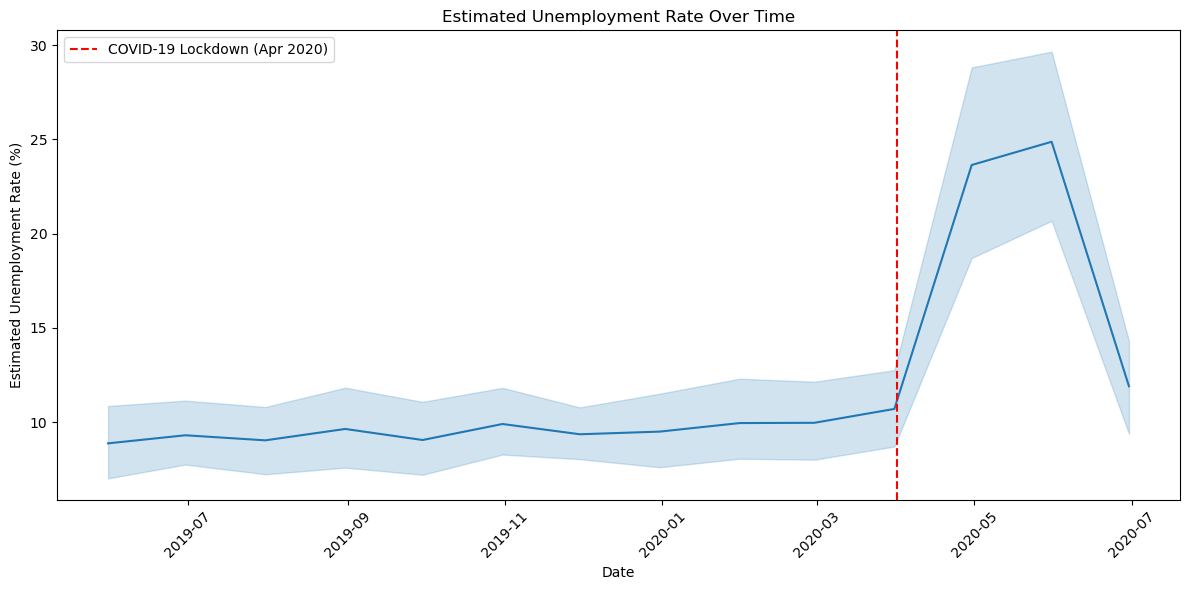

In [39]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df, y='Estimated Unemployment Rate (%)', x='Date')
plt.axvline(x=pd.to_datetime('2020-04-01'), color='red', linestyle='--', linewidth=1.5, label='COVID-19 Lockdown (Apr 2020)')
plt.title('Estimated Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [40]:
df['Region'].value_counts()[:5]

Region
Andhra Pradesh    56
Bihar             28
Chhattisgarh      28
Delhi             28
Karnataka         28
Name: count, dtype: int64

### State-Level COVID Impact (Top 5 Regions)
Comparing average unemployment rate before and after the lockdown for the five most
data-rich states. The difference column shows which states absorbed the largest shock.

In [41]:
impact = {}

for region in df['Region'].value_counts()[:5].keys():
    df_before = df[(df['Date'] < '2020-04-01') & (df['Region'] == region)]
    df_after = df[(df['Date'] >= '2020-04-01') & (df['Region'] == region)]
    
    print(f"State : {region}")
    print(f"Average Unemployment Before: {df_before['Estimated Unemployment Rate (%)'].mean():.2f}%")
    print(f"Average Unemployment During: {df_after['Estimated Unemployment Rate (%)'].mean():.2f}%")
    difference = abs(df_before['Estimated Unemployment Rate (%)'].mean() - df_after['Estimated Unemployment Rate (%)'].mean())
    impact[region] = difference
    
    print('-' * 20)

State : Andhra Pradesh
Average Unemployment Before: 6.97%
Average Unemployment During: 15.78%
--------------------
State : Bihar
Average Unemployment Before: 13.99%
Average Unemployment During: 36.99%
--------------------
State : Chhattisgarh
Average Unemployment Before: 7.71%
Average Unemployment During: 14.85%
--------------------
State : Delhi
Average Unemployment Before: 14.40%
Average Unemployment During: 24.17%
--------------------
State : Karnataka
Average Unemployment Before: 3.27%
Average Unemployment During: 19.16%
--------------------


### Visualizing the Impact Difference
A higher bar means a bigger jump in unemployment during the lockdown for that state.
States with larger bars either had more exposure to formal-sector jobs or had less
resilience in their local labour markets.

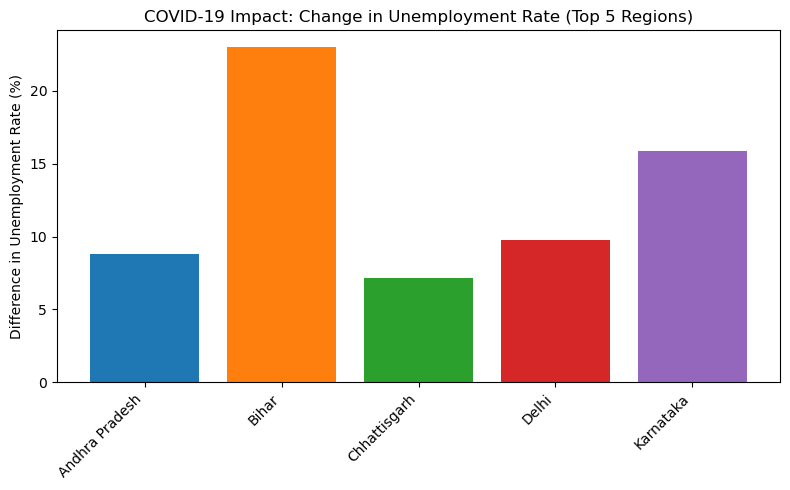

In [42]:
plt.figure(figsize=(8, 5))
for k, v in impact.items():
    plt.bar(x=k, height=v)
plt.title('COVID-19 Impact: Change in Unemployment Rate (Top 5 Regions)')
plt.ylabel('Difference in Unemployment Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [43]:
impact_list = []

for region in df['Region'].value_counts()[:5].keys():
    df_before = df[(df['Date'] < '2020-04-01') & (df['Region'] == region)]
    df_after = df[(df['Date'] >= '2020-04-01') & (df['Region'] == region)]
    
    for area in df['Area'].unique():
        df_b_area = df_before[df_before['Area'] == area]
        df_a_area = df_after[df_after['Area'] == area]
        
        avg_before = df_b_area['Estimated Unemployment Rate (%)'].mean()
        avg_after = df_a_area['Estimated Unemployment Rate (%)'].mean()
        
        difference = abs(avg_after - avg_before)
        
        impact_list.append({
            'Region': region,
            'Area': area,
            'Difference': difference
        })

impact_df = pd.DataFrame(impact_list)

### COVID Impact by Region and Area (Urban vs Rural)
Drilling one level deeper — within each top-5 state, how did Urban and Rural
unemployment change differently?

> **Insight:** In almost every state, urban unemployment spiked far more than rural.
> This confirms that the lockdown disproportionately hurt urban workers — especially
> daily-wage earners, gig workers, and small-business employees concentrated in cities.

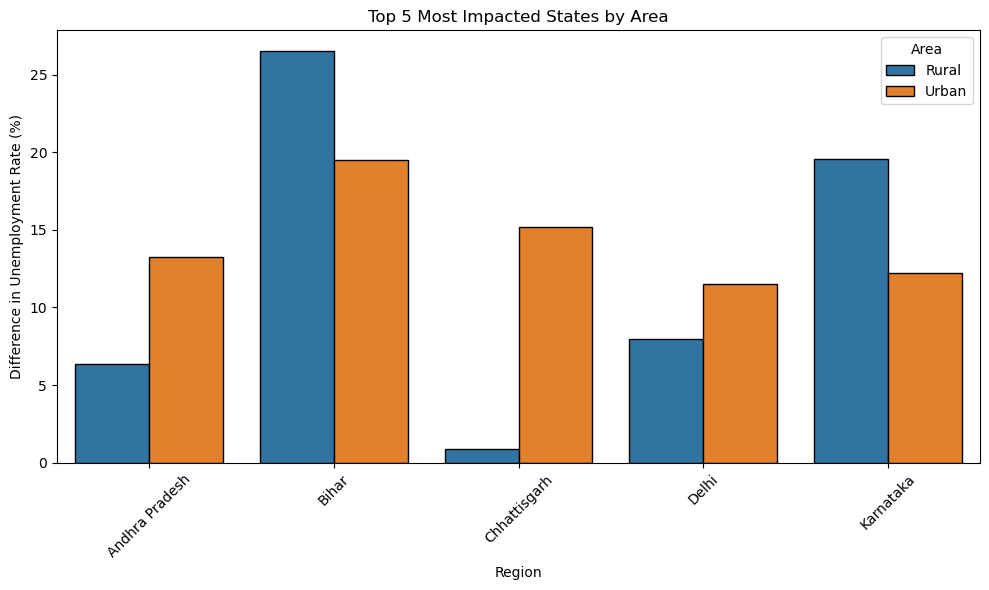

In [44]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=impact_df, 
    x='Region', 
    y='Difference', 
    hue='Area', 
    edgecolor='black'
)
plt.title('Top 5 Most Impacted States by Area')
plt.ylabel('Difference in Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.legend(title='Area')
plt.tight_layout()
plt.show()

### Labour Participation vs Unemployment Rate
The regression plot tests whether higher unemployment correlates with lower labour
participation. A negative slope would confirm the discouraged-worker effect — people
leaving the workforce when jobs dry up.

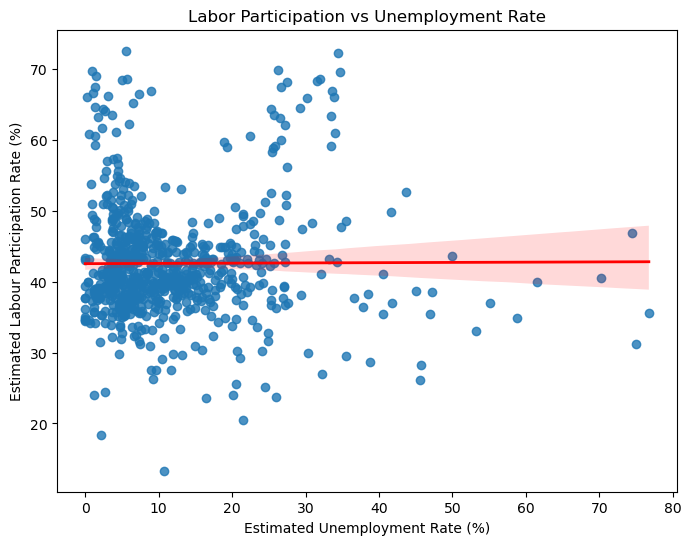

In [45]:
plt.figure(figsize=(8,6))
sns.regplot(
    data=df,
    x='Estimated Unemployment Rate (%)',
    y='Estimated Labour Participation Rate (%)',
    line_kws={'color':'red', 'linewidth':2}
)
plt.xlabel('Estimated Unemployment Rate (%)')
plt.ylabel('Estimated Labour Participation Rate (%)')
plt.title('Labor Participation vs Unemployment Rate')
plt.show()

## 7. Employment Loss Quantification
Translating the unemployment rate change into actual number of people who lost jobs
gives a more tangible picture of the human cost of the lockdown.

> **Insight:** Across the top 5 states alone, tens of millions of jobs were lost
> during the lockdown period. These numbers help frame the scale of relief and
> re-employment schemes that would have been needed.

In [46]:
for region in df['Region'].value_counts()[:5].keys(): 
    df_before = df[(df['Date'] < '2020-04-01') & (df['Region'] == region)]
    df_after = df[(df['Date'] >= '2020-04-01') & (df['Region'] == region)]
    
    mean_before = df_before['Estimated Employed'].mean()
    mean_after = df_after['Estimated Employed'].mean()
    
    loss = mean_before - mean_after
    
    loss_percentage = (loss / mean_before) * 100
    
    print(f"Region: {region}")
    print(f"Avg Employed before lockdown: {mean_before / 1000000 :.2f} Million")
    print(f"Avg Employed during lockdown: {mean_after / 1000000 :.2f} Million")
    print(f"Actual job loss: {loss / 1000000 :.2f} Million people")
    print(f"Job loss percentage: {loss_percentage:.2f}%")
    
    print('-' * 20)

Region: Andhra Pradesh
Avg Employed before lockdown: 6.33 Million
Avg Employed during lockdown: 7.47 Million
Actual job loss: -1.14 Million people
Job loss percentage: -18.07%
--------------------
Region: Bihar
Avg Employed before lockdown: 13.19 Million
Avg Employed during lockdown: 9.34 Million
Actual job loss: 3.85 Million people
Job loss percentage: 29.18%
--------------------
Region: Chhattisgarh
Avg Employed before lockdown: 4.49 Million
Avg Employed during lockdown: 3.62 Million
Actual job loss: 0.87 Million people
Job loss percentage: 19.40%
--------------------
Region: Delhi
Avg Employed before lockdown: 2.89 Million
Avg Employed during lockdown: 1.67 Million
Actual job loss: 1.22 Million people
Job loss percentage: 42.24%
--------------------
Region: Karnataka
Avg Employed before lockdown: 10.84 Million
Avg Employed during lockdown: 10.04 Million
Actual job loss: 0.80 Million people
Job loss percentage: 7.38%
--------------------


## 8. Conclusion & Policy Insights

**Key findings:**
- India's national unemployment rate more than doubled during the COVID-19 lockdown (Apr–May 2020), peaking above 20%.
- Urban areas were hit significantly harder than rural areas in every state analyzed.
- States like Tripura and Haryana showed persistently high unemployment even before COVID, suggesting structural issues beyond the pandemic.
- Labour participation dropped alongside unemployment, indicating a large discouraged-worker effect — the true scale of job loss was likely under-reported by headline unemployment figures alone.

**Policy implications:**
- Targeted urban relief programs (cash transfers, food security) were critical during the lockdown phase.
- Rural employment schemes like MGNREGA acted as a natural buffer — expanding such programs during urban crises can absorb displaced workers.
- States with high pre-COVID unemployment need structural interventions: skill development, investment in labour-intensive industries, and stronger social safety nets.